In [1]:
# %% Imports
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

RAW_PATH = '../data/raw.csv'

In [2]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)

df = df_raw.drop(columns=['hromada', 'source']).reset_index(drop=True)

print(f'Shape: {df.shape}')
df.head()

Shape: (271290, 5)


,oblast,raion,level,started_at,finished_at
0,Vinnytska oblast,NaN,oblast,2022-03-15 16:10:34+00:00,2022-03-15 16:50:07+00:00
1,Zhytomyrska oblast,NaN,oblast,2022-03-15 16:11:25+00:00,2022-03-15 16:54:23+00:00
2,Cherkaska oblast,Umanskyi raion,hromada,2022-03-15 16:11:50+00:00,2022-03-15 16:54:47+00:00
3,Mykolaivska oblast,Pervomaiskyi raion,hromada,2022-03-15 16:14:46+00:00,2022-03-15 16:57:08+00:00
4,Kirovohradska oblast,NaN,oblast,2022-03-15 16:15:11+00:00,2022-03-15 16:54:52+00:00


In [3]:
# Correct formatting of dates and add duration & duration_min
df[['started_at', 'finished_at']] = df[['started_at', 'finished_at']].apply(pd.to_datetime, utc=True)

df['duration'] = df['finished_at'] - df['started_at']
df['duration_min'] = df['duration'].dt.total_seconds() / 60

# City Selection Rationale

Kyiv is treated as a separate focal case. As the capital and political center, it is a high-profile symbolic target whose alert pattern is driven by long-range missile and drone strikes rather than proximity to active frontlines. It is analyzed in depth and used as a reference point for all regional comparisons.

The remaining six cities represent distinct geographic and strategic categories:

## Western rear — Lviv

The westernmost major city, far from any frontline. Expected to show the lowest alert frequency and shortest durations in the dataset, serving as a baseline for what a low-threat environment looks like.

## Southern — Odesa

Ukraine's primary port city on the Black Sea. Faces a distinct threat profile driven by naval and coastal dynamics rather than ground proximity to the front. Strategically important for grain exports and maritime security.

## Northern frontier — Sumy

A regional center sitting directly on the Russian border in the northeast. Has faced cross-border shelling and drone incursions throughout the war, representing sustained low-distance threat exposure rather than campaign-style strikes.

## Eastern urban center — Kharkiv

Ukraine's second-largest city, located roughly 30km from the Russian border. Has been under near-continuous threat since February 2022 including direct ground assault in the early weeks. Represents the highest-intensity sustained urban threat in the dataset.

## Strategic rear — Dnipro

A major industrial and logistics hub on the Dnipro river. Sits behind the frontline but has been struck repeatedly by long-range munitions due to its role as a supply and manufacturing center. Bridges the gap between frontline and rear-area threat profiles.

## Frontline adjacent — Zaporizhzhia

The closest major city to occupied Donetsk oblast, with a significant portion of Zaporizka oblast under Russian control. Faces both front-proximity threats and strikes targeting its critical energy infrastructure, making it analytically distinct from all other cities in the set.

In [4]:
# %% City-level alert dataset

CITY_MAP = {
    'Kyiv':         {'oblast': 'Kyiv City'},
    'Kharkiv':      {'oblast': 'Kharkivska oblast',    'raion': 'Kharkivskyi raion'},
    'Dnipro':       {'oblast': 'Dnipropetrovska oblast','raion': 'Dniprovskyi raion'},
    'Zaporizhzhia': {'oblast': 'Zaporizka oblast',      'raion': 'Zaporizkyi raion'},
    'Odesa':        {'oblast': 'Odeska oblast',         'raion': 'Odeskyi raion'},
    'Lviv':         {'oblast': 'Lvivska oblast',        'raion': 'Lvivskyi raion'},
    'Sumy':         {'oblast': 'Sumska oblast',         'raion': 'Sumskyi raion'},
}

# %% Helper – intervals overlap when neither ends before the other starts
def _overlaps(s1, e1, s2, e2):
    return s1 < e2 and s2 < e1

city_frames = []

for city, mapping in CITY_MAP.items():

    # --- Kyiv: direct match on oblast only ---
    if city == 'Kyiv':
        subset = df[df['oblast'] == mapping['oblast']].copy()
        subset['city'] = city
        subset['_src'] = 'oblast'
        city_frames.append(subset)
        continue

    # --- Other cities: pull oblast and raion rows separately ---
    raion_rows = df[
        (df['oblast'] == mapping['oblast']) &
        (df['raion']  == mapping['raion'])
    ].copy()
    raion_rows['_src'] = 'raion'

    oblast_rows = df[
        (df['oblast'] == mapping['oblast']) &
        (df['raion'].isna())
    ].copy()
    oblast_rows['_src'] = 'oblast'

    # Index raion intervals for fast lookup
    raion_list = list(raion_rows[['started_at', 'finished_at']].itertuples(index=False))

    # Drop oblast rows whose interval overlaps any raion interval
    def _has_overlap(row):
        return any(
            _overlaps(row.started_at, row.finished_at, rs, re)
            for rs, re in raion_list
        )

    mask_drop = oblast_rows.apply(_has_overlap, axis=1)
    kept_oblast = oblast_rows[~mask_drop]

    subset = pd.concat([raion_rows, kept_oblast], ignore_index=True)
    subset['city'] = city
    city_frames.append(subset)

cities_df = (
    pd.concat(city_frames, ignore_index=True)
    # .drop(columns=['_src'], errors='ignore')
    .sort_values(['city', 'started_at'])
    .reset_index(drop=True)
[['city', 'started_at', 'finished_at', 'duration', 'duration_min', '_src']]
)

print(f'Total rows : {len(cities_df):,}')
print(f'\nRows per city:\n{cities_df["city"].value_counts().to_string()}')
cities_df.head(100)

Total rows : 67,642

Rows per city:
city
Zaporizhzhia    16449
Kharkiv         15850
Dnipro          12937
Sumy            10834
Odesa            6011
Kyiv             3952
Lviv             1609


,city,started_at,finished_at,duration,duration_min
_src,,,,,
oblast,49018,49018,49018,49018,49018
raion,18624,18624,18624,18624,18624


In [14]:
# Inspect the duplicates
dupes = cities_df[cities_df.duplicated(subset=['city', 'started_at', 'finished_at'], keep=False)].sort_values(['city', 'started_at', 'finished_at'])

print(f'Duplicate pairs: {len(dupes)}')
print(f'Unique cities affected: {dupes["city"].nunique()}')
dupes.head(100)

Duplicate pairs: 0
Unique cities affected: 0


,city,started_at,finished_at,duration,duration_min,_src


In [6]:
# Deduplicate
cities_df = cities_df.drop_duplicates(subset=['city', 'started_at', 'finished_at']).reset_index(drop=True)
print(f'Shape after dedup: {cities_df.shape}')

Shape after dedup: (36882, 6)


In [13]:
cities_df.groupby(['_src']).count()

,city,started_at,finished_at,duration,duration_min
_src,,,,,
oblast,24611,24611,24611,24611,24611
raion,12271,12271,12271,12271,12271


In [7]:
# %% Missing-value audit
missing = (
    cities_df.isnull()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100)
    .sort_values('missing_pct', ascending=False)
)
print(missing[missing['missing_count'] > 0].to_string())

fig, ax = plt.subplots(figsize=(10, max(3, len(missing.query('missing_pct > 0')) * 0.4 + 1)))
cols_with_na = missing[missing['missing_count'] > 0]
if not cols_with_na.empty:
    ax.barh(cols_with_na.index, cols_with_na['missing_pct'], color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing values by column')
    ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')
    plt.close(fig)

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
No missing values found.


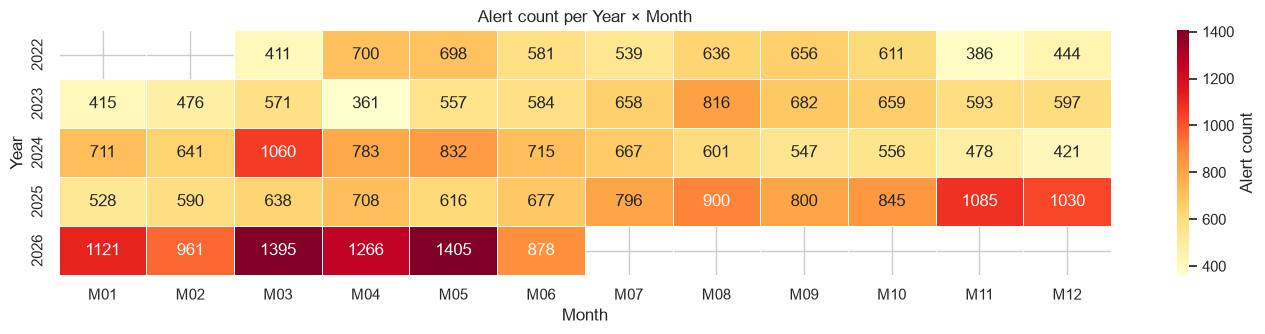

In [8]:
# %% Temporal coverage heatmap
coverage = (
    cities_df.groupby([cities_df['started_at'].dt.year, cities_df['started_at'].dt.month])
    .size()
    .unstack(level=1)
)

coverage.index.name = 'year'
coverage.columns = [f'M{c:02d}' for c in coverage.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(coverage) * 0.5 + 1)))
sns.heatmap(
    coverage, annot=True, fmt='.0f', linewidths=0.5,
    cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Alert count'}
)
ax.set_title('Alert count per Year × Month')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

Note that this heat map is not very useful for analysis of real data about alerts in Ukraine, because it focuses only on 7 cities and considers each city alert as separate entity. But it is useful to see the shape of the data and general tendency: from end of 2025 to now air alerts are much more frequent. Currently, I have a hypothesis that this is impact of near frontline theritories, like Kharkiv and Dnipro,

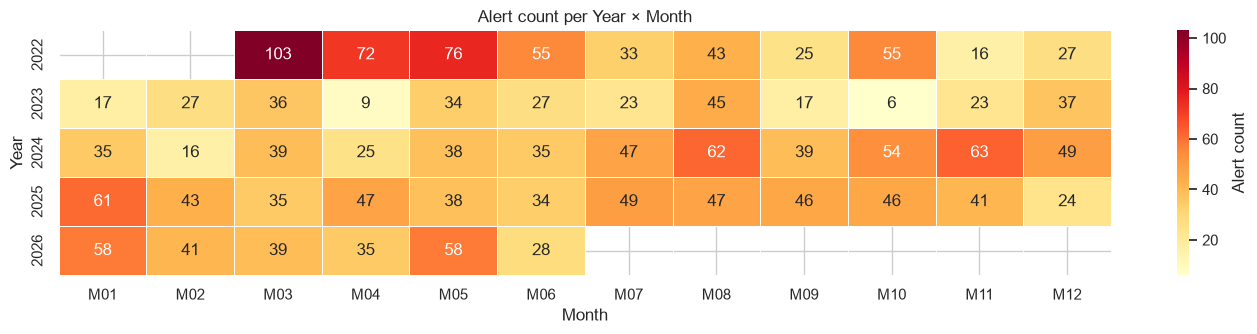

In [9]:
# Verify for Kyiv
kyiv_df = cities_df.query('city == "Kyiv"')

# %% Temporal coverage heatmap
coverage = (
    kyiv_df.groupby([kyiv_df['started_at'].dt.year, kyiv_df['started_at'].dt.month])
    .size()
    .unstack(level=1)
)

coverage.index.name = 'year'
coverage.columns = [f'M{c:02d}' for c in coverage.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(coverage) * 0.5 + 1)))
sns.heatmap(
    coverage, annot=True, fmt='.0f', linewidths=0.5,
    cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Alert count'}
)
ax.set_title('Alert count per Year × Month')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

In [10]:
# %% Alert counts by city / year / source
summary = (
    cities_df.groupby([
        'city',
        cities_df['started_at'].dt.year.rename('year'),
        '_src'
    ])
    .size()
    .unstack('_src', fill_value=0)
    .rename_axis(columns=None)
)

summary

oblast  raion
city         year               
Dnipro       2022    1130      5
             2023    1431      0
             2024    2037      0
             2025     933    436
             2026       0    863
Kharkiv      2022    1323    174
             2023    1654      1
             2024     949      1
             2025       0   2402
             2026       0   2555
Kyiv         2022     505      0
             2023     301      0
             2024     502      0
             2025     511      0
             2026     259      0
Lviv         2022     230      0
             2023     191      0
             2024     209      0
             2025     115     23
             2026       0     63
Odesa        2022     545     10
             2023     444      0
             2024     799      0
             2025     621    233
             2026       0    631
Sumy         2022     513     15
             2023     925      2
             2024    1558      0
             2025    1071    775
             2026       0    987
Zaporizhzhia 2022    1197     15
             2023    2020      0
             2024    1956      1
             2025     682   1411
             2026       0   1668

In [11]:
cities_df.groupby(['_src']).count()

,city,started_at,finished_at,duration,duration_min
_src,,,,,
oblast,24611,24611,24611,24611,24611
raion,12271,12271,12271,12271,12271


In [15]:
cities_df.groupby([cities_df['started_at'].dt.year, '_src']).size().unstack()

_src,oblast,raion
started_at,,
2022,5443,219
2023,6966,3
2024,8010,2
2025,3933,5280
2026,259,6767


In [22]:
cities_df[(cities_df['started_at'].dt.year == 2022) & (cities_df['_src'] == 'raion')].reset_index(drop=True).groupby('city').count()

,started_at,finished_at,duration,duration_min,_src
city,,,,,
Dnipro,5,5,5,5,5
Kharkiv,174,174,174,174,174
Odesa,10,10,10,10,10
Sumy,15,15,15,15,15
Zaporizhzhia,15,15,15,15,15


In [26]:
cities_df.head()
cities_df.to_csv('../data/wraggled_cities.csv', index=False)

At this moment I consider the data as clear and ready for doing analytics. Also note that previously calculations specifically for Kyiv were correct because it does not have raions, while other oblasts (which are associated with their city centers) were significantly underestimated, which relates to introducing new alert system by raions. Below you can see clarification of choice for cities